/opt/anaconda3/envs/myenv/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Loading and merging data...
Available columns in session 1: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s1', 'ndt_mean_s1', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s2', 'ndt_mean_s2', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: participant_ID
Merged

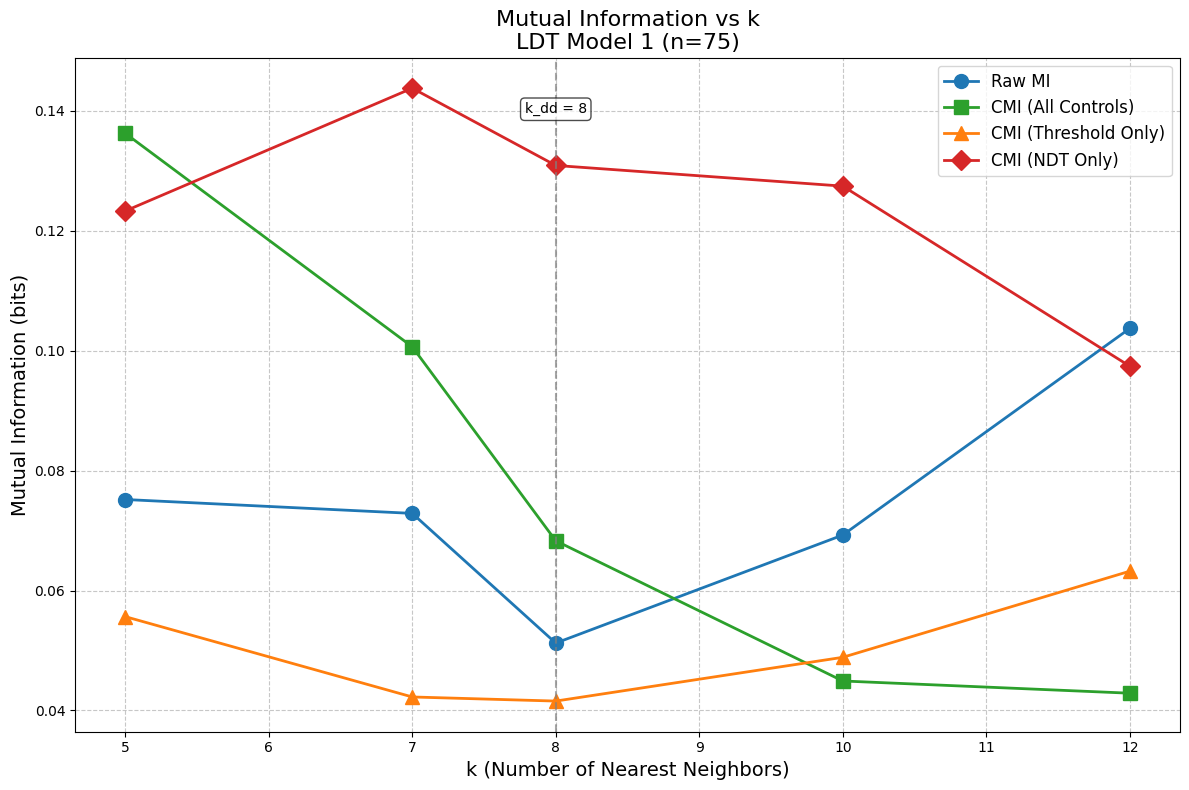

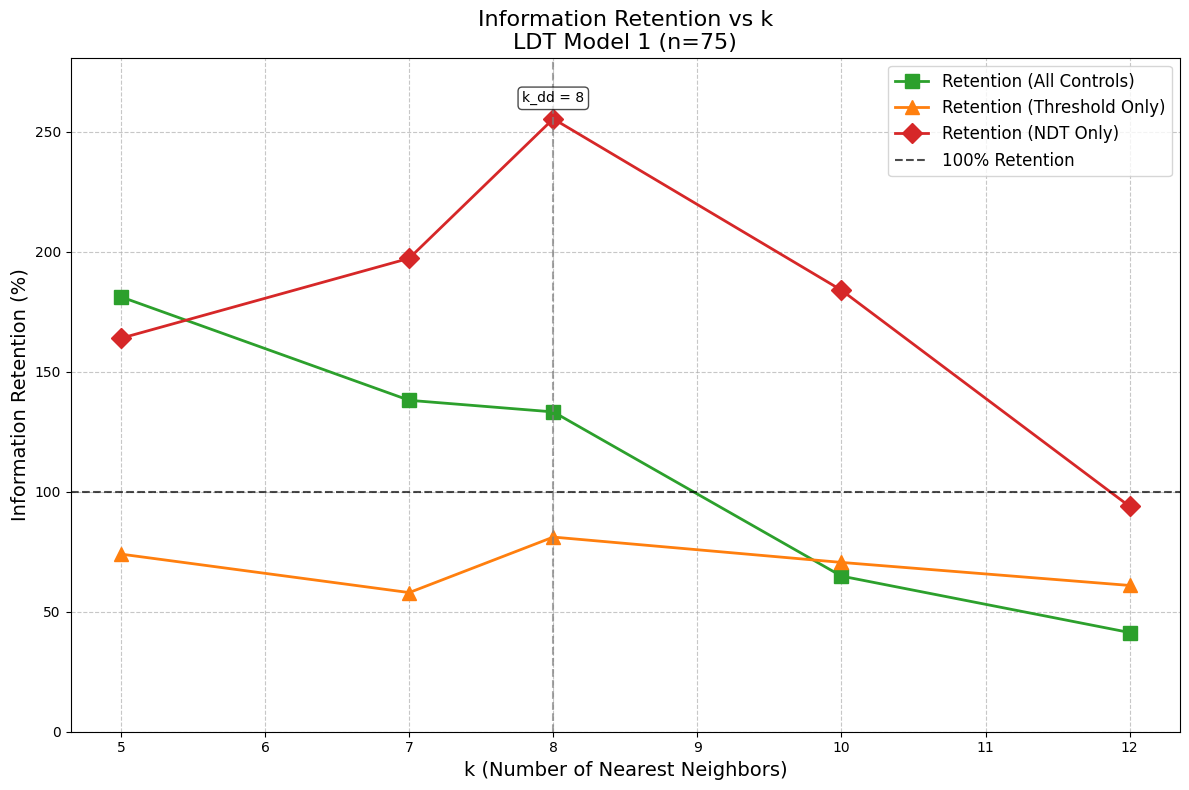

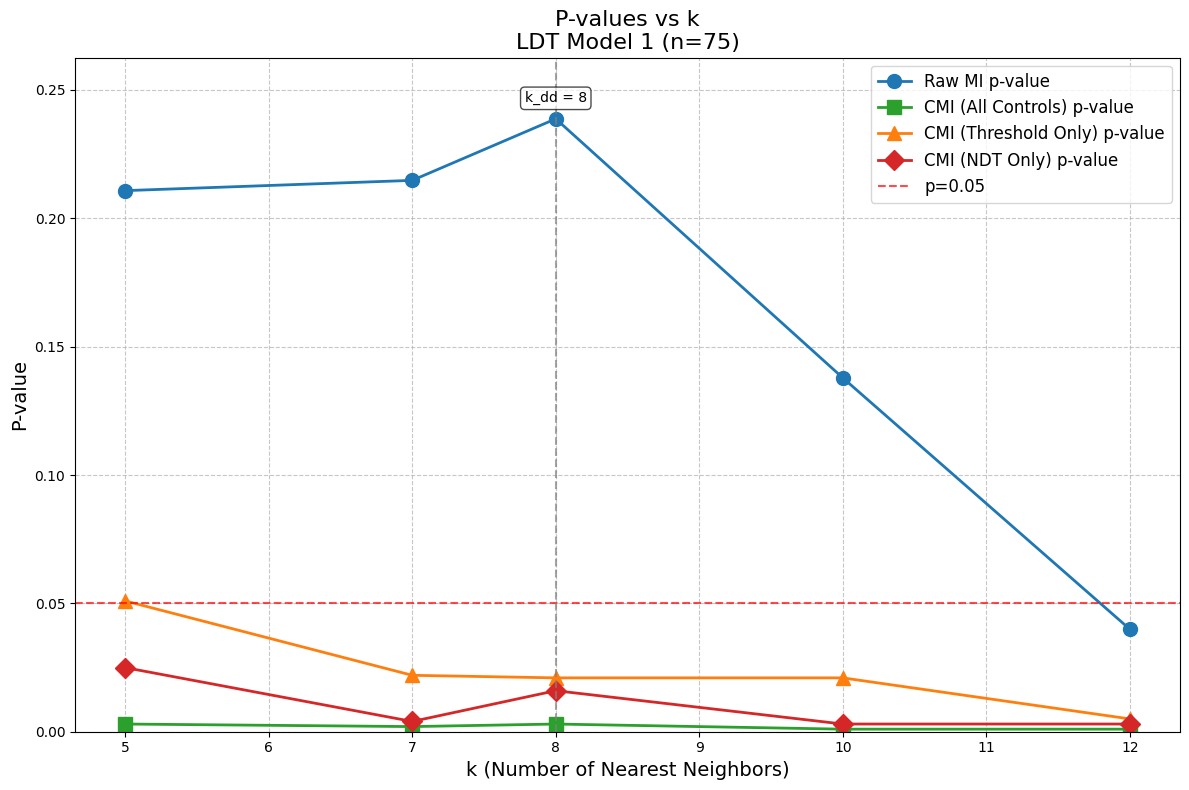


Summary Results for RMT Model 2
Number of Participants: 75
Sensitivity Analysis: 4 subsamples (each using 60 participants)
k Value    Raw MI (bits)   Raw MI p-value  Cond MI All (bits) Cond MI All p-value Retention All (%) Cond MI Thresh (bits) Cond MI Thresh p-value Retention Thresh (%) Cond MI NDT (bits) Cond MI NDT p-value Retention NDT (%) Sensitivity Mean±SD
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
5           0.075         0.2108           0.136*        0.0030          181.2            0.056         0.0509          74.0             0.123*        0.0250          164.0           0.043±0.053
7           0.073         0.2148           0.101*        0.0020          138.1            0.042*        0.0220          58.0             0.144*        0.0040          197.3           0.042±0.044
8           0.051         0.2388           0.068*        0.003

In [ ]:
# Import the necessary modules
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from KSG_MI_First import KSGMutualInformationAnalyzer, load_and_merge

# File paths for your data
session1_path = 'Model2 LDT RMT/EZ_recognition_memory_part1_transformed.csv'
session2_path = 'Model2 LDT RMT/EZ_recognition_memory_part2_transformed.csv'

# Custom dataset name (optional)
dataset_name = "RMT Model 2"

# Load and merge the data
print("Loading and merging data...")
df_merged = load_and_merge(session1_path, session2_path)
print(f"Merged data contains {len(df_merged)} participants")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"Data-driven k value (sqrt(N)): {k_data_driven}")

# Define k values to analyze
# You can customize this list based on your needs
k_values = [5, 7, 10, k_data_driven,12]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort
print(f"Using k values: {k_values}")

# Store results
results = {}

# Run analysis with different k values
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000  # Using fewer permutations for notebook (faster)
    )

# Plot results
analyzer.plot_results(
    results[k_values[-1]], 
    all_k_results=results, 
    dataset_name=dataset_name
)

# Print summary table
analyzer.print_summary_table(
    all_k_results=results, 
    session1_path=session1_path,
    output_csv_path="output_results.csv"  # Optional - save to CSV
)

# Display comprehensive results in a cleaner format for notebook
from IPython.display import display, HTML

html_output = "<h3>Comprehensive Results Summary</h3>"
html_output += "<table border='1'>"
html_output += "<tr><th>k Value</th><th>MI Type</th><th>Value</th><th>p-value</th><th>Retention</th></tr>"

for k in k_values:
    # Raw MI row
    html_output += f"<tr><td rowspan='4'>{k}</td><td>Raw MI</td><td>{results[k]['ksg_mi'][0]:.4f}</td><td>{results[k]['ksg_mi'][1]:.4f}</td><td>100%</td></tr>"
    
    # All controls row
    html_output += f"<tr><td>All Parameters</td><td>{results[k].get('cond_mi_all', 0):.4f}</td><td>{results[k].get('p_value_all', 1):.4f}</td><td>{results[k].get('retention_all', 0):.1f}%</td></tr>"
    
    # Threshold row
    html_output += f"<tr><td>Threshold Only</td><td>{results[k].get('cond_mi_thresh', 0):.4f}</td><td>{results[k].get('p_value_thresh', 1):.4f}</td><td>{results[k].get('retention_thresh', 0):.1f}%</td></tr>"
    
    # NDT row
    html_output += f"<tr><td>NDT Only</td><td>{results[k].get('cond_mi_ndt', 0):.4f}</td><td>{results[k].get('p_value_ndt', 1):.4f}</td><td>{results[k].get('retention_ndt', 0):.1f}%</td></tr>"

html_output += "</table>"

display(HTML(html_output))

# MODEL 2 LDT

Available columns in session 1: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s1', 'ndt_mean_s1', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s2', 'ndt_mean_s2', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: participant_ID
Loading and merging data...
Availa

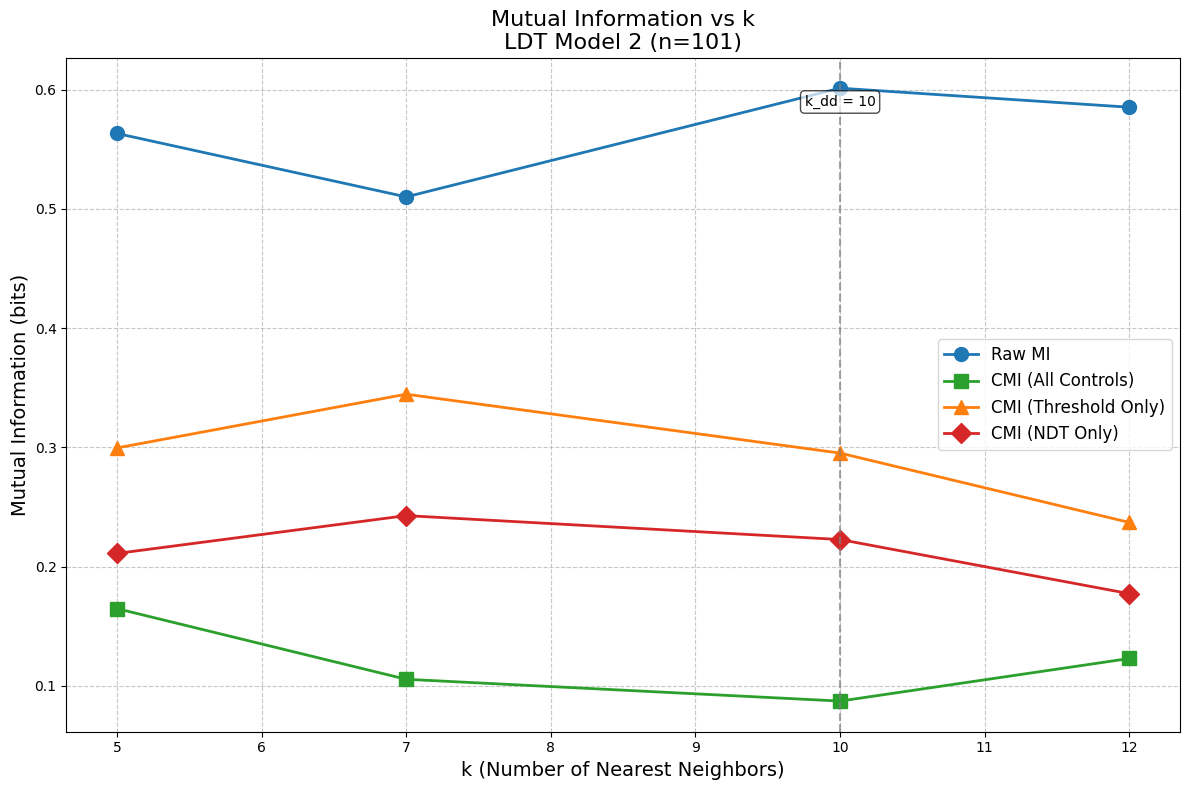

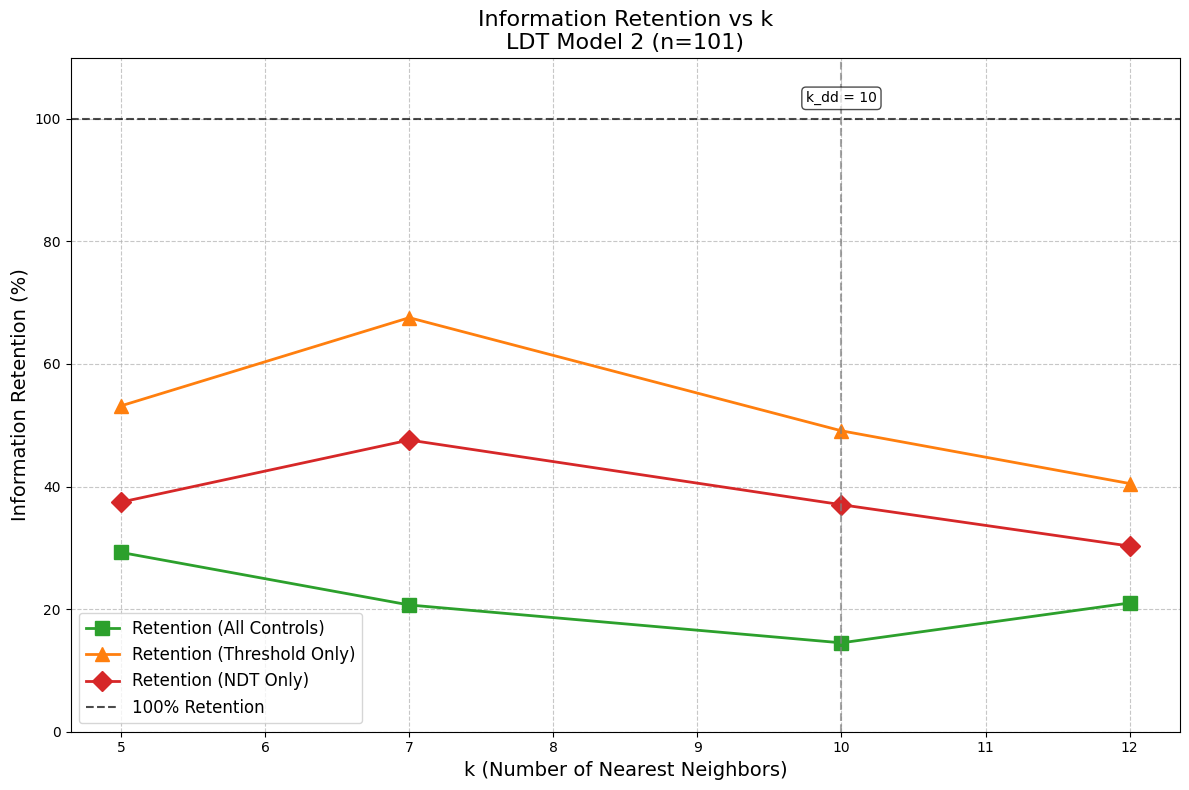

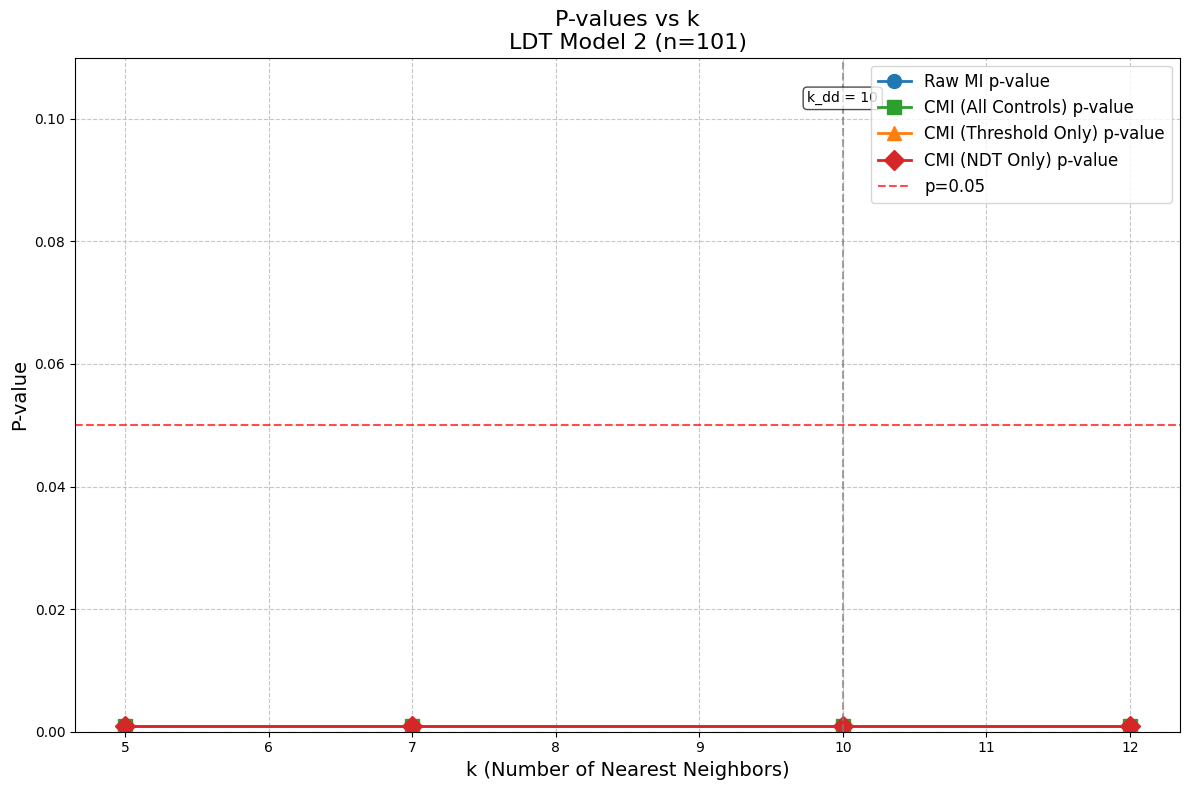


Summary Results for LDT Model 2
Number of Participants: 101
Sensitivity Analysis: 4 subsamples (each using 80 participants)
k Value    Raw MI (bits)   Raw MI p-value  Cond MI All (bits) Cond MI All p-value Retention All (%) Cond MI Thresh (bits) Cond MI Thresh p-value Retention Thresh (%) Cond MI NDT (bits) Cond MI NDT p-value Retention NDT (%) Sensitivity Mean±SD
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
5           0.563*        0.0010           0.165*        0.0010          29.3             0.299*        0.0010          53.2             0.211*        0.0010          37.5            0.379±0.069
7           0.510*        0.0010           0.105*        0.0010          20.7             0.345*        0.0010          67.6             0.243*        0.0010          47.6            0.390±0.059
10          0.601*        0.0010           0.087*        0.00

In [2]:
import KSG_MI
import numpy as np

# Load data
session1_path = 'Model2 LDT RMT/EZ_lexical_decision_part1_transformed.csv'
session2_path = 'Model2 LDT RMT/EZ_lexical_decision_part2_transformed.csv'
df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Custom dataset name (optional)
dataset_name = "LDT Model 2"

# Load and merge the data
print("Loading and merging data...")
df_merged = load_and_merge(session1_path, session2_path)
print(f"Merged data contains {len(df_merged)} participants")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"Data-driven k value (sqrt(N)): {k_data_driven}")

# Define k values to analyze
# You can customize this list based on your needs
k_values = [5, 7, 10, k_data_driven,12]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort
print(f"Using k values: {k_values}")

# Store results
results = {}

# Run analysis with different k values
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000  # Using fewer permutations for notebook (faster)
    )

# Plot results
analyzer.plot_results(
    results[k_values[-1]], 
    all_k_results=results, 
    dataset_name=dataset_name
)

# Print summary table
analyzer.print_summary_table(
    all_k_results=results, 
    session1_path=session1_path,
    output_csv_path="output_results.csv"  # Optional - save to CSV
)

# Display comprehensive results in a cleaner format for notebook
from IPython.display import display, HTML

html_output = "<h3>Comprehensive Results Summary</h3>"
html_output += "<table border='1'>"
html_output += "<tr><th>k Value</th><th>MI Type</th><th>Value</th><th>p-value</th><th>Retention</th></tr>"

for k in k_values:
    # Raw MI row
    html_output += f"<tr><td rowspan='4'>{k}</td><td>Raw MI</td><td>{results[k]['ksg_mi'][0]:.4f}</td><td>{results[k]['ksg_mi'][1]:.4f}</td><td>100%</td></tr>"
    
    # All controls row
    html_output += f"<tr><td>All Parameters</td><td>{results[k].get('cond_mi_all', 0):.4f}</td><td>{results[k].get('p_value_all', 1):.4f}</td><td>{results[k].get('retention_all', 0):.1f}%</td></tr>"
    
    # Threshold row
    html_output += f"<tr><td>Threshold Only</td><td>{results[k].get('cond_mi_thresh', 0):.4f}</td><td>{results[k].get('p_value_thresh', 1):.4f}</td><td>{results[k].get('retention_thresh', 0):.1f}%</td></tr>"
    
    # NDT row
    html_output += f"<tr><td>NDT Only</td><td>{results[k].get('cond_mi_ndt', 0):.4f}</td><td>{results[k].get('p_value_ndt', 1):.4f}</td><td>{results[k].get('retention_ndt', 0):.1f}%</td></tr>"

html_output += "</table>"

display(HTML(html_output))

# Model1 RMT 

Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s1', 'ndt_mean_s1', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s2', 'ndt_mean_s2', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: ID
Loading and merging data...
Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1


Analyzing with k=7

Analyzing with k=9

Analyzing with k=10

Analyzing with k=12


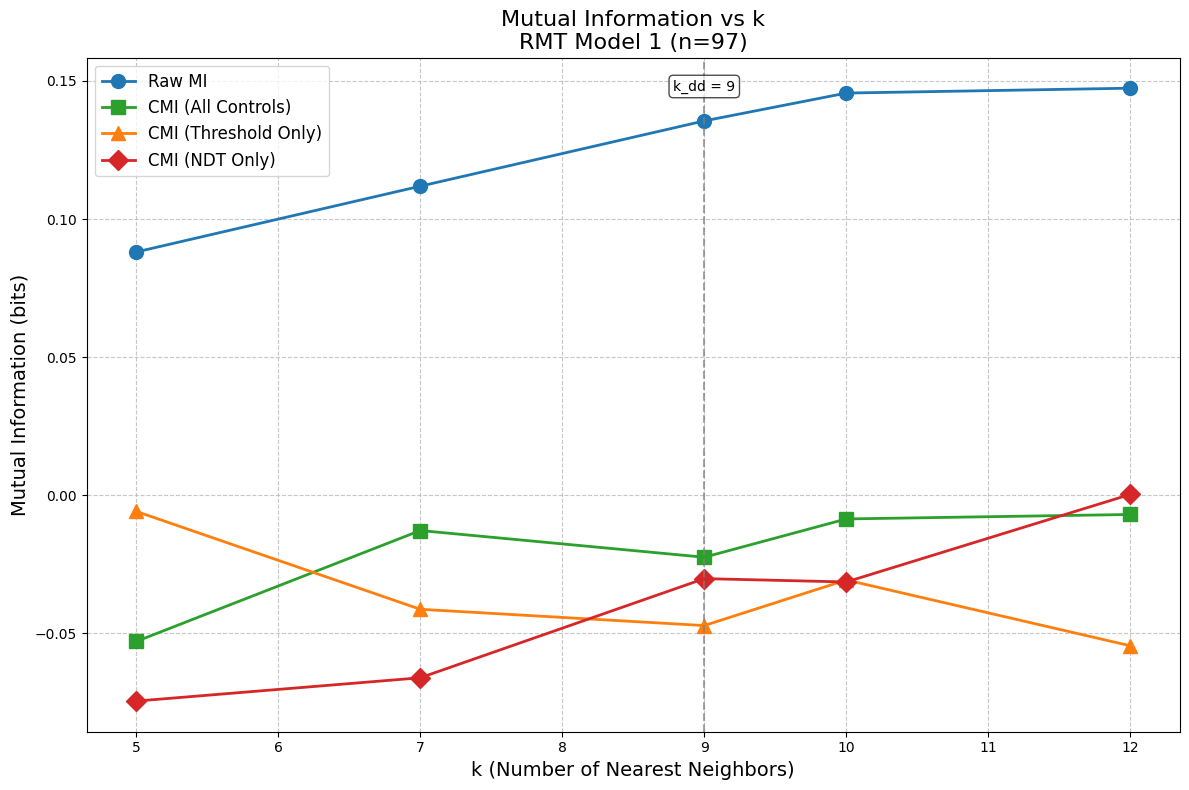

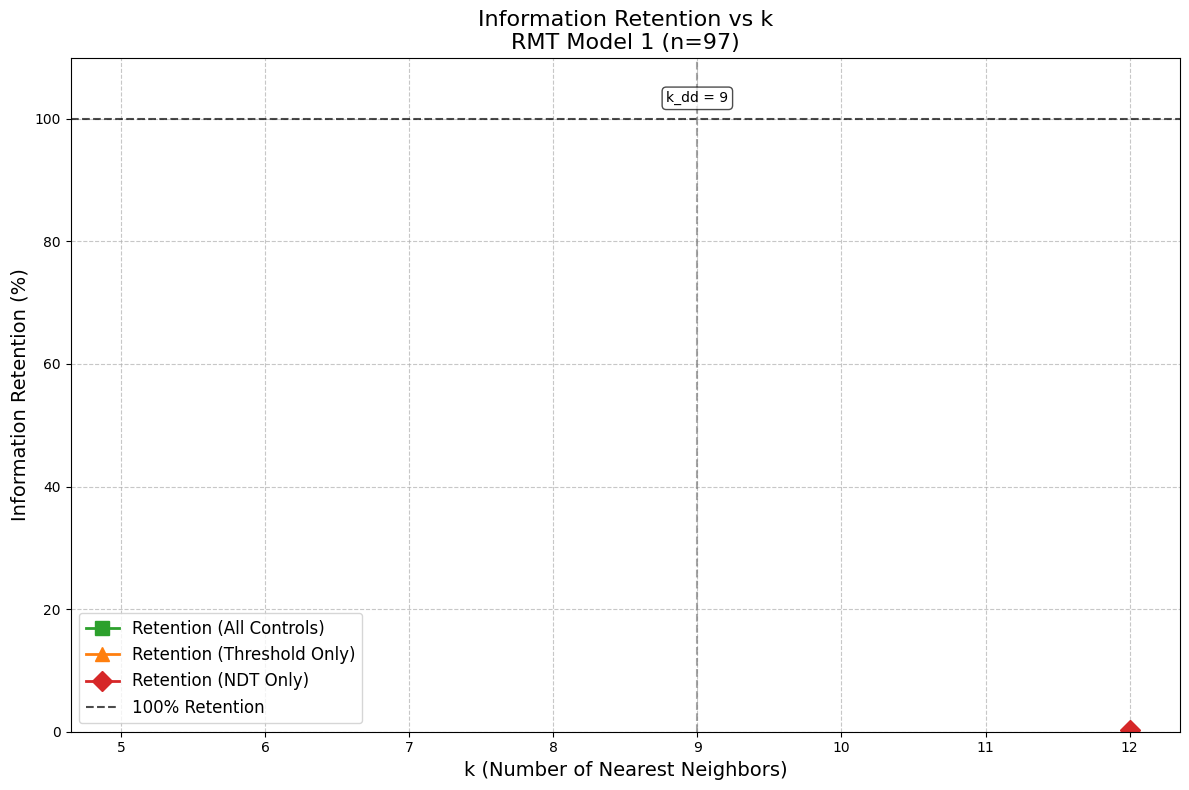

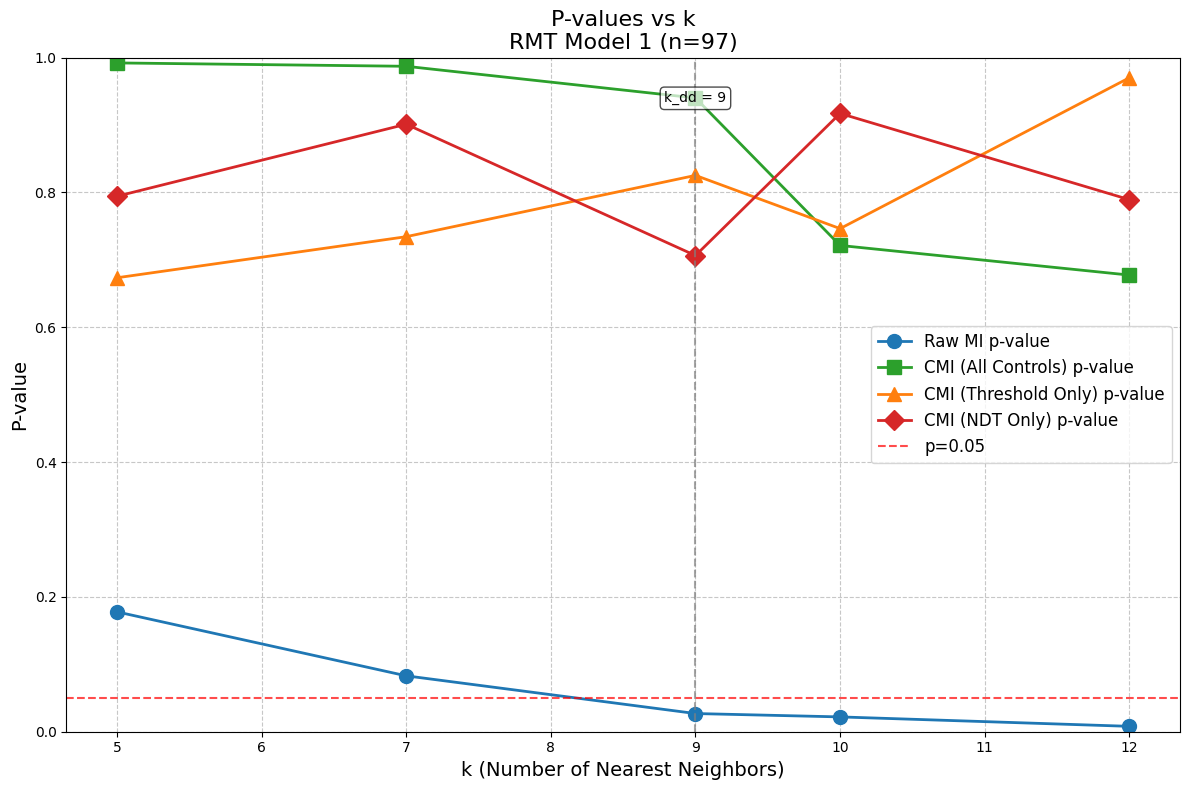


Summary Results for RMT Model 1
Number of Participants: 97
Sensitivity Analysis: 4 subsamples (each using 77 participants)
k Value    Raw MI (bits)   Raw MI p-value  Cond MI All (bits) Cond MI All p-value Retention All (%) Cond MI Thresh (bits) Cond MI Thresh p-value Retention Thresh (%) Cond MI NDT (bits) Cond MI NDT p-value Retention NDT (%) Sensitivity Mean±SD
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
5           0.088         0.1778          -0.053         0.9920          -60.1           -0.006         0.6733          -6.6            -0.075         0.7942          -84.6           0.076±0.050
7           0.112         0.0829          -0.013         0.9870          -11.4           -0.041         0.7343          -36.9           -0.066         0.9011          -59.1           0.098±0.042
9           0.136*        0.0270          -0.022         0.940

In [3]:
import KSG_MI
# Load data
session1_path = 'Model1 LDT RMT/rmt_session_1_data_transformed.csv'
session2_path = 'Model1 LDT RMT/rmt_session_2_data_transformed.csv'
df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Custom dataset name (optional)
dataset_name = "RMT Model 1"

# Load and merge the data
print("Loading and merging data...")
df_merged = load_and_merge(session1_path, session2_path)
print(f"Merged data contains {len(df_merged)} participants")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"Data-driven k value (sqrt(N)): {k_data_driven}")

# Define k values to analyze
# You can customize this list based on your needs
k_values = [5, 7, 10, k_data_driven,12]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort
print(f"Using k values: {k_values}")

# Store results
results = {}

# Run analysis with different k values
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000  # Using fewer permutations for notebook (faster)
    )

# Plot results
analyzer.plot_results(
    results[k_values[-1]], 
    all_k_results=results, 
    dataset_name=dataset_name
)

# Print summary table
analyzer.print_summary_table(
    all_k_results=results, 
    session1_path=session1_path,
    output_csv_path="output_results.csv"  # Optional - save to CSV
)

# Display comprehensive results in a cleaner format for notebook
from IPython.display import display, HTML

html_output = "<h3>Comprehensive Results Summary</h3>"
html_output += "<table border='1'>"
html_output += "<tr><th>k Value</th><th>MI Type</th><th>Value</th><th>p-value</th><th>Retention</th></tr>"

for k in k_values:
    # Raw MI row
    html_output += f"<tr><td rowspan='4'>{k}</td><td>Raw MI</td><td>{results[k]['ksg_mi'][0]:.4f}</td><td>{results[k]['ksg_mi'][1]:.4f}</td><td>100%</td></tr>"
    
    # All controls row
    html_output += f"<tr><td>All Parameters</td><td>{results[k].get('cond_mi_all', 0):.4f}</td><td>{results[k].get('p_value_all', 1):.4f}</td><td>{results[k].get('retention_all', 0):.1f}%</td></tr>"
    
    # Threshold row
    html_output += f"<tr><td>Threshold Only</td><td>{results[k].get('cond_mi_thresh', 0):.4f}</td><td>{results[k].get('p_value_thresh', 1):.4f}</td><td>{results[k].get('retention_thresh', 0):.1f}%</td></tr>"
    
    # NDT row
    html_output += f"<tr><td>NDT Only</td><td>{results[k].get('cond_mi_ndt', 0):.4f}</td><td>{results[k].get('p_value_ndt', 1):.4f}</td><td>{results[k].get('retention_ndt', 0):.1f}%</td></tr>"

html_output += "</table>"

display(HTML(html_output))

# Model 1 LDT

Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s1', 'ndt_mean_s1', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s2', 'ndt_mean_s2', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: ID
Loading and merging data...
Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1

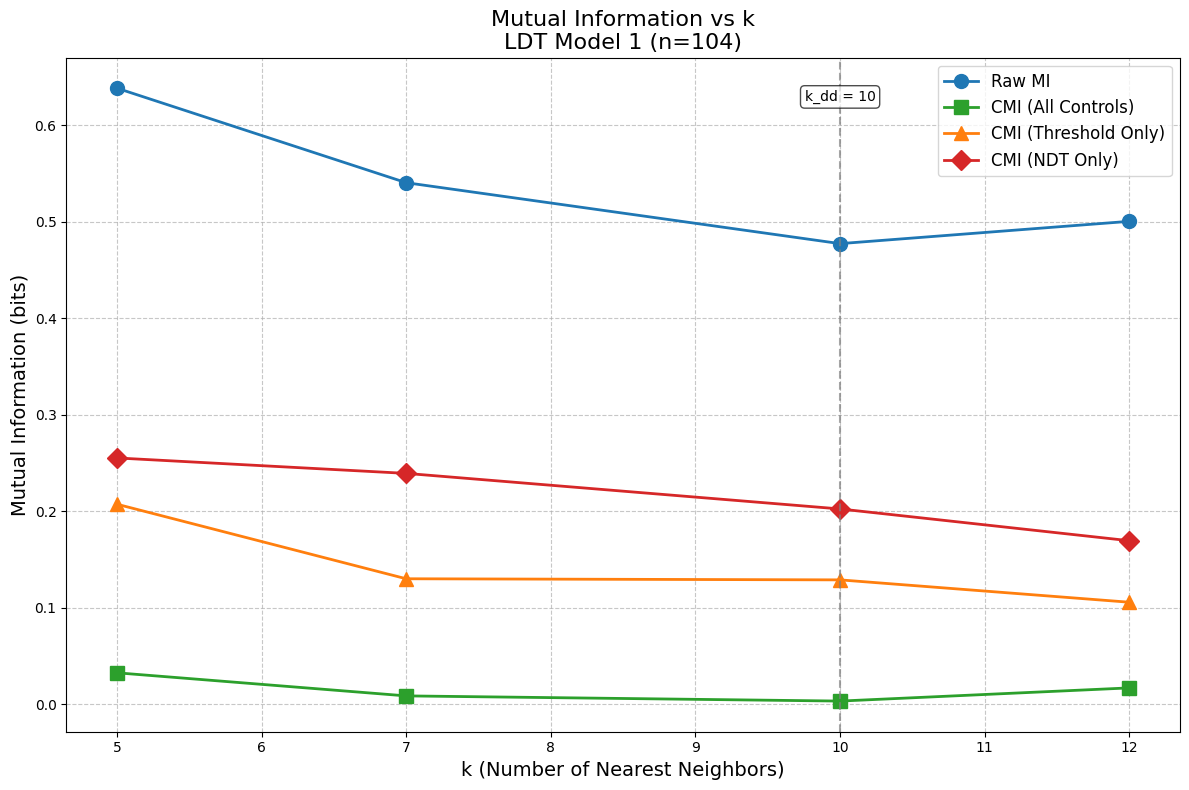

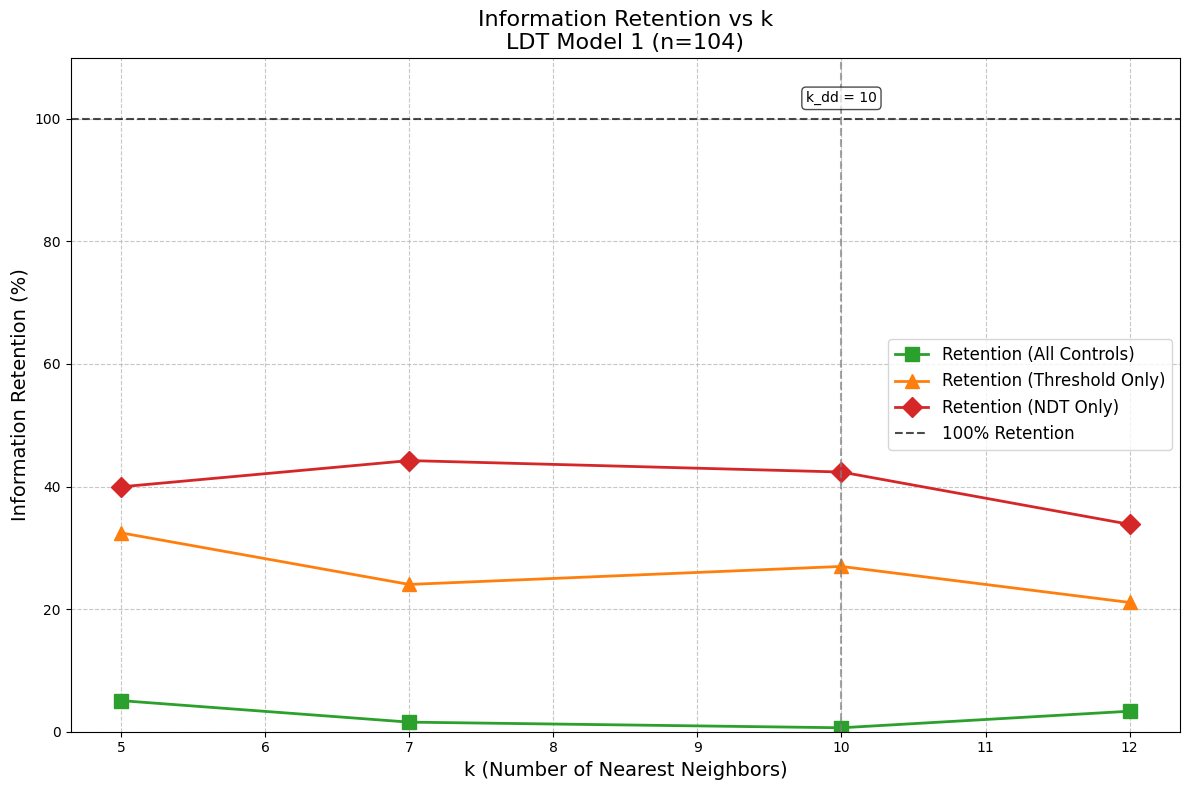

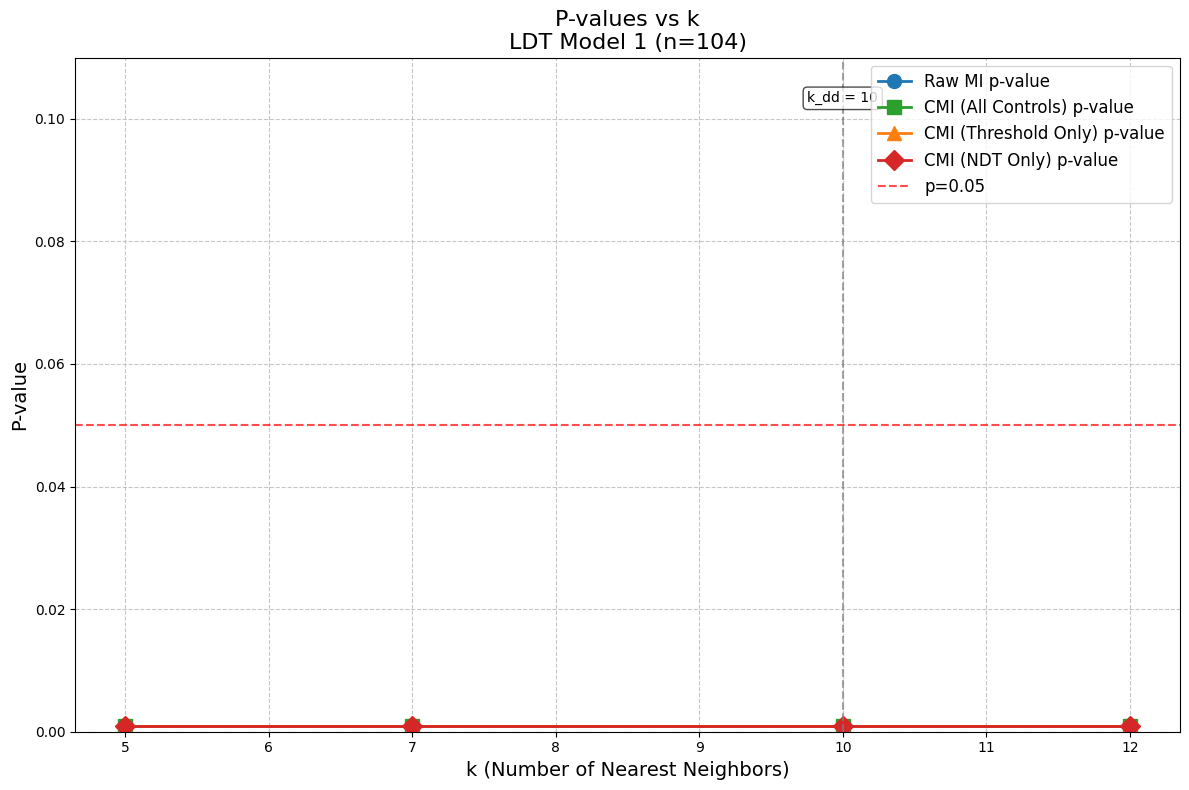


Summary Results for LDT Model 1
Number of Participants: 104
Sensitivity Analysis: 4 subsamples (each using 83 participants)
k Value    Raw MI (bits)   Raw MI p-value  Cond MI All (bits) Cond MI All p-value Retention All (%) Cond MI Thresh (bits) Cond MI Thresh p-value Retention Thresh (%) Cond MI NDT (bits) Cond MI NDT p-value Retention NDT (%) Sensitivity Mean±SD
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
5           0.638*        0.0010           0.032*        0.0010          5.1              0.207*        0.0010          32.4             0.255*        0.0010          40.0            0.405±0.069
7           0.540*        0.0010           0.008*        0.0010          1.6              0.130*        0.0010          24.0             0.239*        0.0010          44.2            0.349±0.052
10          0.477*        0.0010           0.003*        0.00

In [4]:
import KSG_MI
import numpy as np

# Load data
session1_path = 'Model1 LDT RMT/ldt_session_1_data_transformed.csv'
session2_path = 'Model1 LDT RMT/ldt_session_2_data_transformed.csv'
df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Custom dataset name (optional)
dataset_name = "LDT Model 1"

# Load and merge the data
print("Loading and merging data...")
df_merged = load_and_merge(session1_path, session2_path)
print(f"Merged data contains {len(df_merged)} participants")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"Data-driven k value (sqrt(N)): {k_data_driven}")

# Define k values to analyze
# You can customize this list based on your needs
k_values = [5, 7, 10, k_data_driven,12]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort
print(f"Using k values: {k_values}")

# Store results
results = {}

# Run analysis with different k values
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000  # Using fewer permutations for notebook (faster)
    )

# Plot results
analyzer.plot_results(
    results[k_values[-1]], 
    all_k_results=results, 
    dataset_name=dataset_name
)

# Print summary table
analyzer.print_summary_table(
    all_k_results=results, 
    session1_path=session1_path,
    output_csv_path="output_results.csv"  # Optional - save to CSV
)

# Display comprehensive results in a cleaner format for notebook
from IPython.display import display, HTML

html_output = "<h3>Comprehensive Results Summary</h3>"
html_output += "<table border='1'>"
html_output += "<tr><th>k Value</th><th>MI Type</th><th>Value</th><th>p-value</th><th>Retention</th></tr>"

for k in k_values:
    # Raw MI row
    html_output += f"<tr><td rowspan='4'>{k}</td><td>Raw MI</td><td>{results[k]['ksg_mi'][0]:.4f}</td><td>{results[k]['ksg_mi'][1]:.4f}</td><td>100%</td></tr>"
    
    # All controls row
    html_output += f"<tr><td>All Parameters</td><td>{results[k].get('cond_mi_all', 0):.4f}</td><td>{results[k].get('p_value_all', 1):.4f}</td><td>{results[k].get('retention_all', 0):.1f}%</td></tr>"
    
    # Threshold row
    html_output += f"<tr><td>Threshold Only</td><td>{results[k].get('cond_mi_thresh', 0):.4f}</td><td>{results[k].get('p_value_thresh', 1):.4f}</td><td>{results[k].get('retention_thresh', 0):.1f}%</td></tr>"
    
    # NDT row
    html_output += f"<tr><td>NDT Only</td><td>{results[k].get('cond_mi_ndt', 0):.4f}</td><td>{results[k].get('p_value_ndt', 1):.4f}</td><td>{results[k].get('retention_ndt', 0):.1f}%</td></tr>"

html_output += "</table>"

display(HTML(html_output))

# Model 1 ELP

Loading and merging data...
Available columns in session 1: ['Unnamed: 0', 'participant', 'v1', 'v2', 'zr', 'a_mean_s1', 'ndt_mean_s1', 'sndt', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'participant', 'v1', 'v2', 'zr', 'a_mean_s2', 'ndt_mean_s2', 'sndt', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Using identifier column: participant
Merged data contains 806 participants
Data-driven k value (sqrt(N)): 28
Using k values: [5, 7

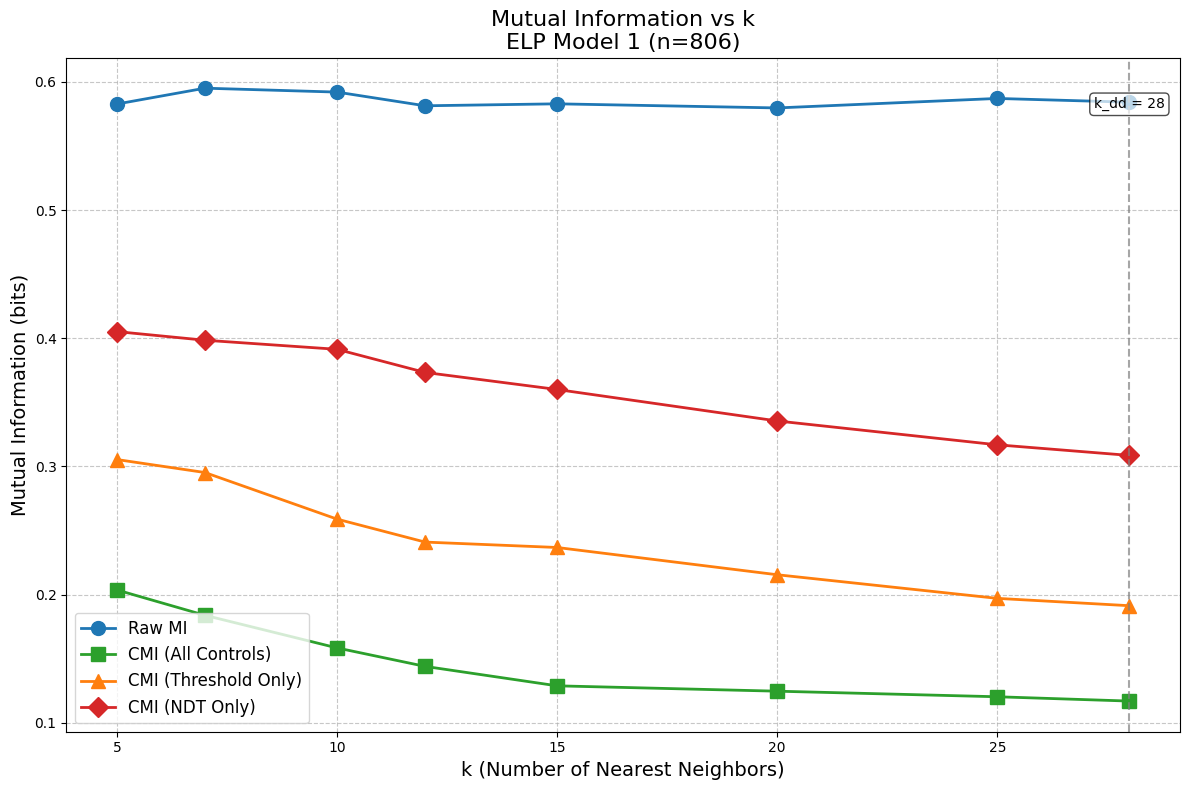

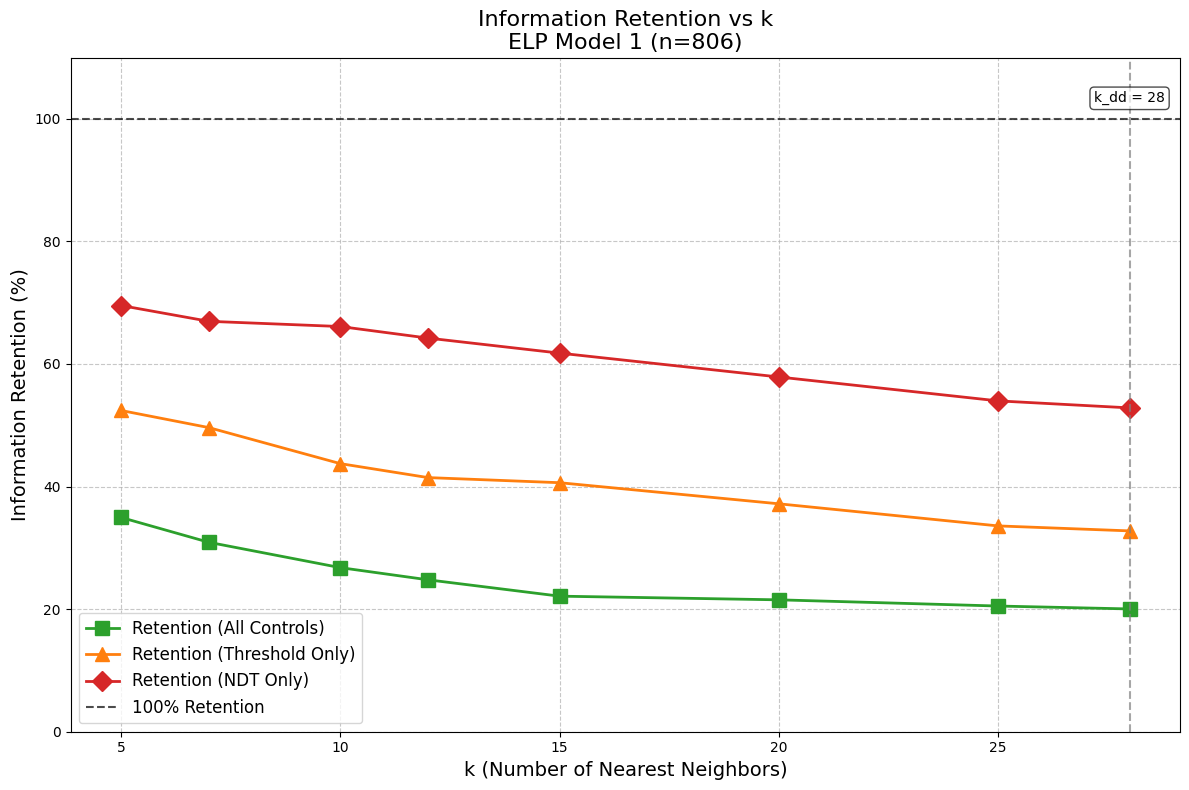

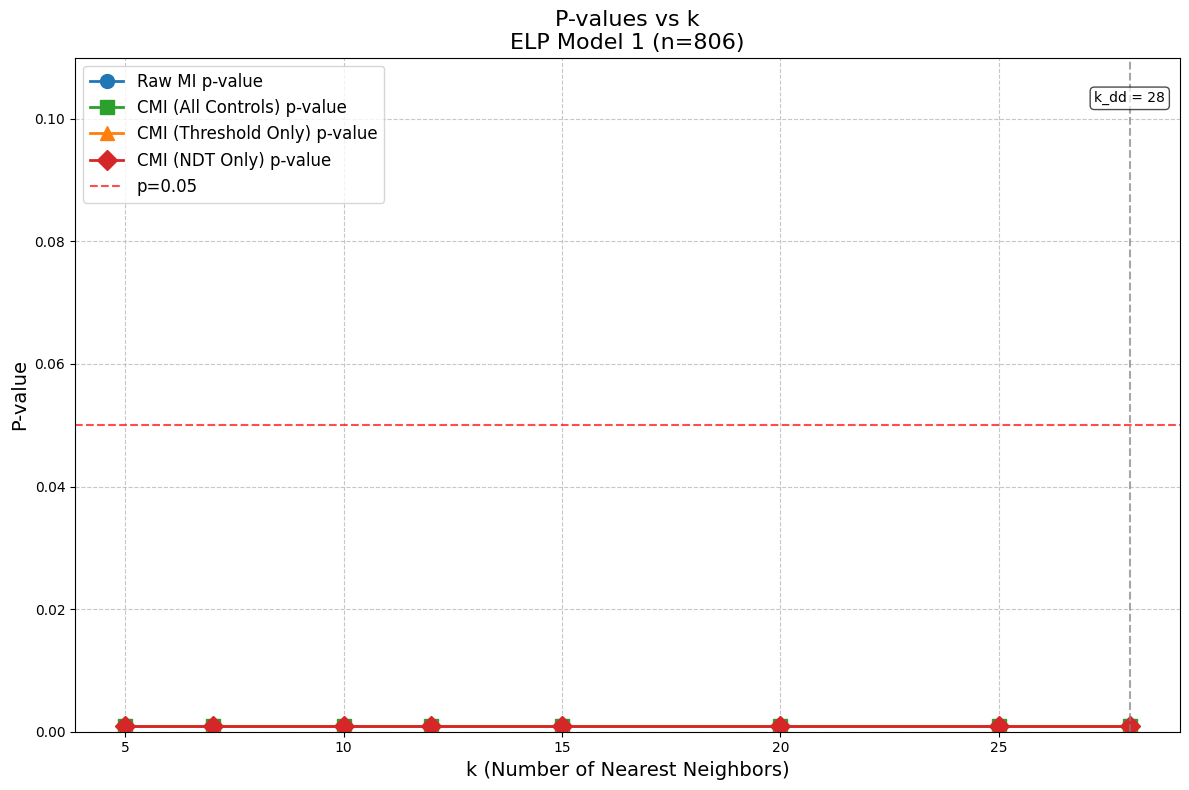


Summary Results for ELP Model 1
Number of Participants: 806
Sensitivity Analysis: 4 subsamples (each using 644 participants)
k Value    Raw MI (bits)   Raw MI p-value  Cond MI All (bits) Cond MI All p-value Retention All (%) Cond MI Thresh (bits) Cond MI Thresh p-value Retention Thresh (%) Cond MI NDT (bits) Cond MI NDT p-value Retention NDT (%) Sensitivity Mean±SD
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
5           0.583*        0.0010           0.204*        0.0010          35.0             0.305*        0.0010          52.4             0.405*        0.0010          69.5            0.407±0.029
7           0.595*        0.0010           0.184*        0.0010          30.9             0.295*        0.0010          49.6             0.398*        0.0010          67.0            0.411±0.024
10          0.592*        0.0010           0.158*        0.0

In [5]:
import KSG_MI
import numpy as np

# Load data
session1_path = 'Model1 ELP/Transformed_recoverd_param_ELP_S1_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'
session2_path = 'Model1 ELP/Transformed_recoverd_param_ELP_S2_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'

# Custom dataset name (optional)
dataset_name = "ELP Model 1"

# Load and merge the data
print("Loading and merging data...")
df_merged = load_and_merge(session1_path, session2_path)
print(f"Merged data contains {len(df_merged)} participants")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"Data-driven k value (sqrt(N)): {k_data_driven}")

# Define k values to analyze
# You can customize this list based on your needs
k_values = [5, 7, 10, k_data_driven,12,15,20, 25]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort
print(f"Using k values: {k_values}")

# Store results
results = {}

# Run analysis with different k values
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000  # Using fewer permutations for notebook (faster)
    )

# Plot results
analyzer.plot_results(
    results[k_values[-1]], 
    all_k_results=results, 
    dataset_name=dataset_name
)

# Print summary table
analyzer.print_summary_table(
    all_k_results=results, 
    session1_path=session1_path,
    output_csv_path="output_results.csv"  # Optional - save to CSV
)

# Display comprehensive results in a cleaner format for notebook
from IPython.display import display, HTML

html_output = "<h3>Comprehensive Results Summary</h3>"
html_output += "<table border='1'>"
html_output += "<tr><th>k Value</th><th>MI Type</th><th>Value</th><th>p-value</th><th>Retention</th></tr>"

for k in k_values:
    # Raw MI row
    html_output += f"<tr><td rowspan='4'>{k}</td><td>Raw MI</td><td>{results[k]['ksg_mi'][0]:.4f}</td><td>{results[k]['ksg_mi'][1]:.4f}</td><td>100%</td></tr>"
    
    # All controls row
    html_output += f"<tr><td>All Parameters</td><td>{results[k].get('cond_mi_all', 0):.4f}</td><td>{results[k].get('p_value_all', 1):.4f}</td><td>{results[k].get('retention_all', 0):.1f}%</td></tr>"
    
    # Threshold row
    html_output += f"<tr><td>Threshold Only</td><td>{results[k].get('cond_mi_thresh', 0):.4f}</td><td>{results[k].get('p_value_thresh', 1):.4f}</td><td>{results[k].get('retention_thresh', 0):.1f}%</td></tr>"
    
    # NDT row
    html_output += f"<tr><td>NDT Only</td><td>{results[k].get('cond_mi_ndt', 0):.4f}</td><td>{results[k].get('p_value_ndt', 1):.4f}</td><td>{results[k].get('retention_ndt', 0):.1f}%</td></tr>"

html_output += "</table>"

display(HTML(html_output))

Model 2 ELP

Loading and merging data...
Available columns in session 1: ['Unnamed: 0', 'participant', 'v1', 'v2', 'a_mean_s1', 'ndt_mean_s1', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'participant', 'v1', 'v2', 'a_mean_s2', 'ndt_mean_s2', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Using identifier column: participant
Merged data contains 806 participants
Data-driven k value (sqrt(N)): 28
Using k values: [5, 7, 10, 12, 28]

Analyzing wit

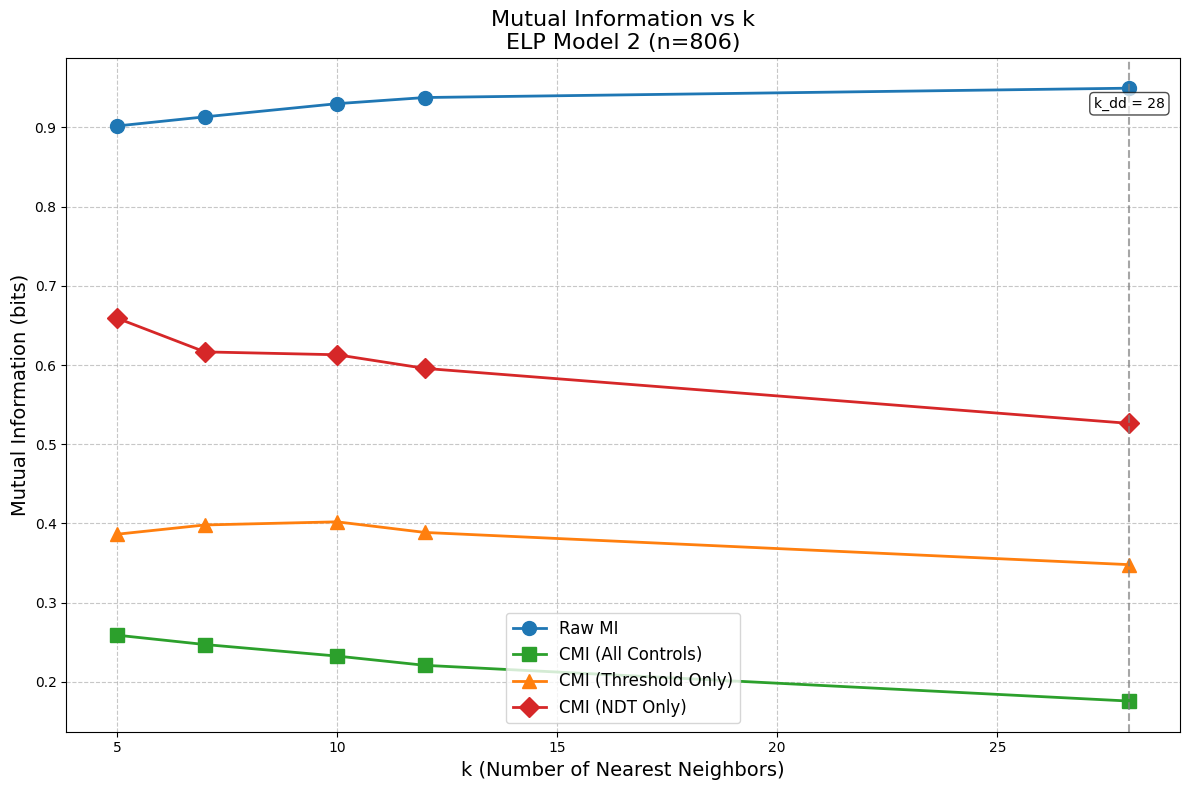

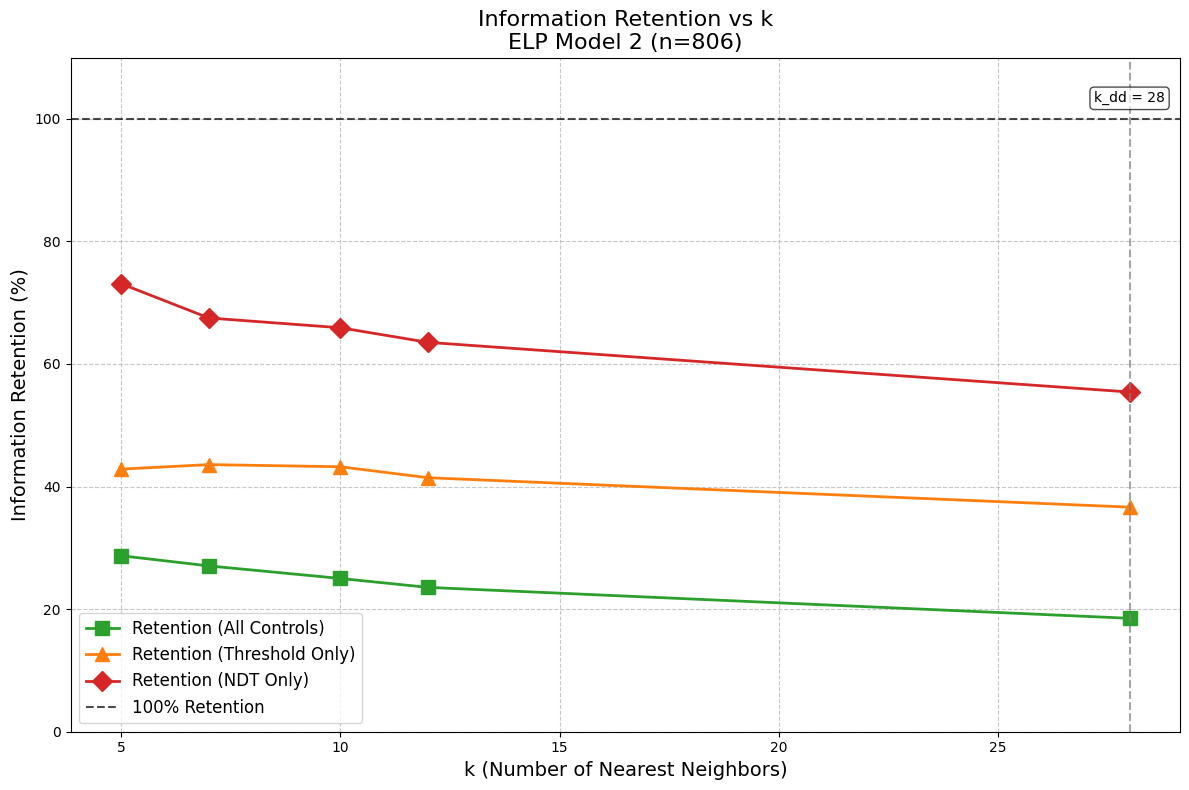

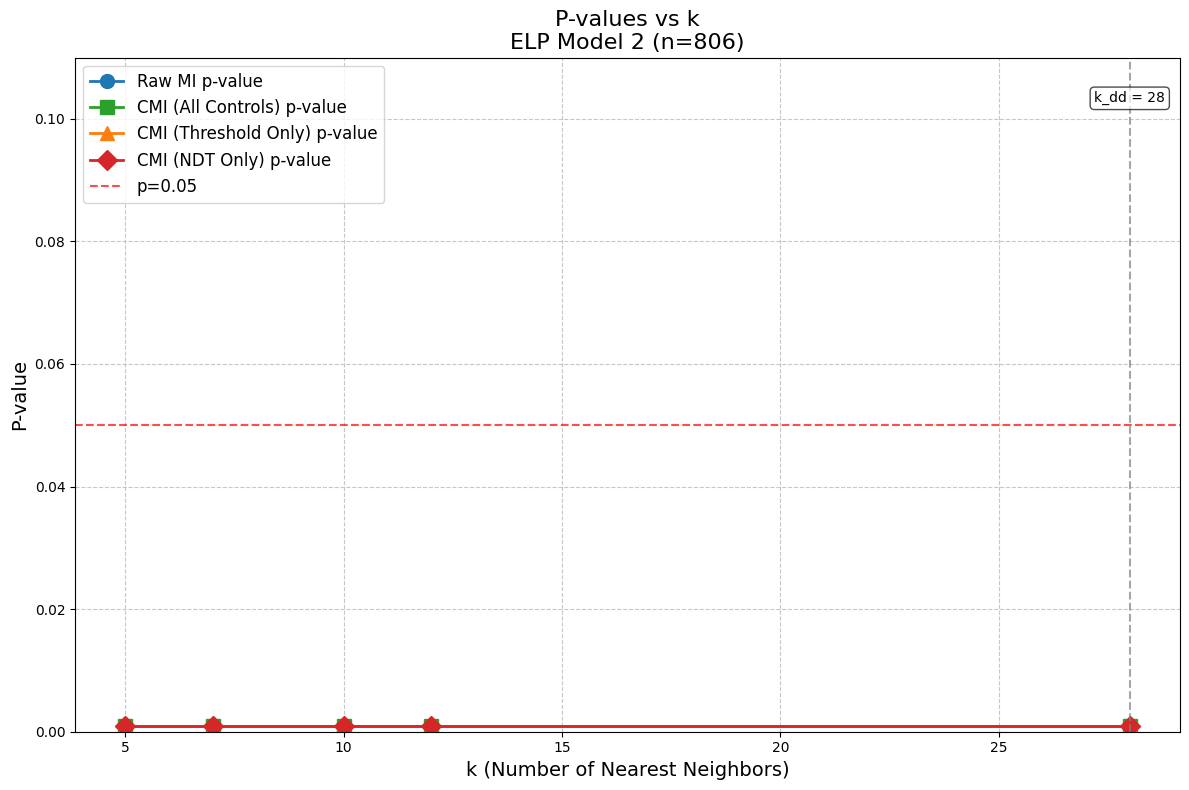


Summary Results for ELP Model 2
Number of Participants: 806
Sensitivity Analysis: 4 subsamples (each using 644 participants)
k Value    Raw MI (bits)   Raw MI p-value  Cond MI All (bits) Cond MI All p-value Retention All (%) Cond MI Thresh (bits) Cond MI Thresh p-value Retention Thresh (%) Cond MI NDT (bits) Cond MI NDT p-value Retention NDT (%) Sensitivity Mean±SD
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
5           0.902*        0.0010           0.259*        0.0010          28.7             0.386*        0.0010          42.8             0.659*        0.0010          73.1            0.632±0.028
7           0.913*        0.0010           0.247*        0.0010          27.1             0.398*        0.0010          43.6             0.617*        0.0010          67.5            0.637±0.029
10          0.930*        0.0010           0.233*        0.0

In [6]:
import KSG_MI
import numpy as np

# Load data
session1_path = 'Model2 ELP/Transformed_recoverd_param_ELP_S1_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'
session2_path = 'Model2 ELP/Transformed_recoverd_param_ELP_S2_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'

# Custom dataset name (optional)
dataset_name = "ELP Model 2"

# Load and merge the data
print("Loading and merging data...")
df_merged = load_and_merge(session1_path, session2_path)
print(f"Merged data contains {len(df_merged)} participants")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"Data-driven k value (sqrt(N)): {k_data_driven}")

# Define k values to analyze
# You can customize this list based on your needs
k_values = [5, 7, 10, k_data_driven,12]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort
print(f"Using k values: {k_values}")

# Store results
results = {}

# Run analysis with different k values
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000  # Using fewer permutations for notebook (faster)
    )

# Plot results
analyzer.plot_results(
    results[k_values[-1]], 
    all_k_results=results, 
    dataset_name=dataset_name
)

# Print summary table
analyzer.print_summary_table(
    all_k_results=results, 
    session1_path=session1_path,
    output_csv_path="output_results.csv"  # Optional - save to CSV
)

# Display comprehensive results in a cleaner format for notebook
from IPython.display import display, HTML

html_output = "<h3>Comprehensive Results Summary</h3>"
html_output += "<table border='1'>"
html_output += "<tr><th>k Value</th><th>MI Type</th><th>Value</th><th>p-value</th><th>Retention</th></tr>"

for k in k_values:
    # Raw MI row
    html_output += f"<tr><td rowspan='4'>{k}</td><td>Raw MI</td><td>{results[k]['ksg_mi'][0]:.4f}</td><td>{results[k]['ksg_mi'][1]:.4f}</td><td>100%</td></tr>"
    
    # All controls row
    html_output += f"<tr><td>All Parameters</td><td>{results[k].get('cond_mi_all', 0):.4f}</td><td>{results[k].get('p_value_all', 1):.4f}</td><td>{results[k].get('retention_all', 0):.1f}%</td></tr>"
    
    # Threshold row
    html_output += f"<tr><td>Threshold Only</td><td>{results[k].get('cond_mi_thresh', 0):.4f}</td><td>{results[k].get('p_value_thresh', 1):.4f}</td><td>{results[k].get('retention_thresh', 0):.1f}%</td></tr>"
    
    # NDT row
    html_output += f"<tr><td>NDT Only</td><td>{results[k].get('cond_mi_ndt', 0):.4f}</td><td>{results[k].get('p_value_ndt', 1):.4f}</td><td>{results[k].get('retention_ndt', 0):.1f}%</td></tr>"

html_output += "</table>"

display(HTML(html_output))